# Financial Ratio Quantile Strategies
---
### Constructing & Optimizing Rank-Based Equity Portfolios 
In this analysis, we evaluate the efficacy of single-factor and multi-factor signals within a market-neutral, long-short equity framework. 

Using a monthly rebalancing schedule and dynamic funding costs (LIBOR/SOFR), we test top-and-bottom decile trading strategies based on Value (P/E Ratio), Quality (ROI), and Safety (Debt/Market Cap).

In [1]:
import databento as db 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import itertools
import glob 
import os

# 1. Data Assembly | Defining the Universe 

The analysis covers the period from January 2018 to June 2023. We utilized the Zacks Fundamentals B database (Tables: FC, FR, MT, MKTV, SHRC, HDM) with a strict set of inclusion criteria: 

**Data Completeness:** End-of-day adjusted closing prices are available over the entire analysis period from January 2018 through June 2023.

**Liquidity Threshold:** The market value (as reported in MKTV) never fell below $100MM at any point during the window.

**Leverage Constraint:** A Debt/Market Cap ratio exceeding 0.1 at least once, ensuring the universe excludes firms with effectively zero leverage.
   
**Sector Exclusions:** Removal of all tickers classified within the Automotive, Financial, or Insurance sectors.

**Metric Validity:** Feasible and continuous calculation of Debt/Market Cap, Return on Investment (ROI), and Price/Earnings (P/E) ratios.

We first import the **MKTV (Market Value)** file, which tracks daily market capitalization and enterprise value for over 19,500 companies, including over 10,000 delisted stocks.

We store this in a Pandas DataFrame 'mktv_df,' before **filtering for companies whose Market Value never dips below $100MM** -- one of our 6 criteria. 

In [2]:
mktv_df = pd.read_csv('MKTV.csv') 
mktv_df['per_end_date'] = pd.to_datetime(mktv_df['per_end_date'])

In [3]:
mktv_df.head(3) # check first few rows 

,ticker,m_ticker,comp_name,fye,per_type,per_end_date,active_ticker_flag,mkt_val,ep_val
0,A,A2,AGILENT TECH,10,Q,2023-09-30,Y,32717.11,34122.11
1,A,A2,AGILENT TECH,10,Q,2023-06-30,Y,35518.94,37076.94
2,A,A2,AGILENT TECH,10,Q,2023-03-31,Y,40907.39,42390.39


In [4]:
min_vals = mktv_df.groupby('m_ticker')['mkt_val'].transform('min') # Identify minimum values in 'mkt_val' column 

# Filter for rows where the company's lowest recorded market value is >= 100
df_filtered = mktv_df[
    (min_vals >= 100) & 
    (mktv_df['per_end_date'] > '2017-3-31') # filter for dates after March 2017 --> we retain 9 months of additional data for testing purposes 
].copy()

print(f"Original rows: {len(mktv_df)}") # Check the result
print(f"Filtered rows: {len(df_filtered)}")

Original rows: 1058327
Filtered rows: 170342


We next use the **MT (Master Table)** as a directory, containing descriptive information such as sector/industry classifications, company names, tickers, etc. 

We merge this data with our first DataFrame, and **drop inactive companies.** 

In [5]:
mt_df = pd.read_csv('MT.csv', low_memory=False) # load sector descriptions from .csv file 
mt_df = mt_df.iloc[:, :17]

In [6]:
# Merge sector descriptions (zacks_x_sector_code) with our original DataFrame (MKTV). 
cols_to_merge = [1, 11, 12, 13, 14, 15, 16]
mt_subset = mt_df.iloc[:, cols_to_merge]
merged_df = pd.merge(df_filtered, mt_subset, on='ticker', how='left')

df_final = merged_df.dropna(subset=['zacks_x_sector_desc']).copy() # drop inactive companies -- recored as NaN value in 'zacks_x_ind_desc' column 
df_final.reset_index(drop=True, inplace=True) # Reset the index to keep it clean (0, 1, 2...)

In [7]:
df_final.head(2)

,ticker,m_ticker,comp_name,fye,per_type,per_end_date,active_ticker_flag,mkt_val,ep_val,zacks_x_ind_code,zacks_x_ind_desc,zacks_x_sector_code,zacks_x_sector_desc,zacks_m_ind_code,zacks_m_ind_desc
0,A,A2,AGILENT TECH,10,Q,2023-09-30,Y,32717.11,34122.11,260.0,ELEC TEST EQUIPTMENT,10.0,Computer and Technology,34.0,ELECTRONICS
1,A,A2,AGILENT TECH,10,Q,2023-06-30,Y,35518.94,37076.94,260.0,ELEC TEST EQUIPTMENT,10.0,Computer and Technology,34.0,ELECTRONICS


We next **examine the remaining companies by sector.**

In [8]:
df_unique = df_final.drop_duplicates(subset=['ticker'])
print(f"Total Unique Companies: {len(df_unique)}")

Total Unique Companies: 3401


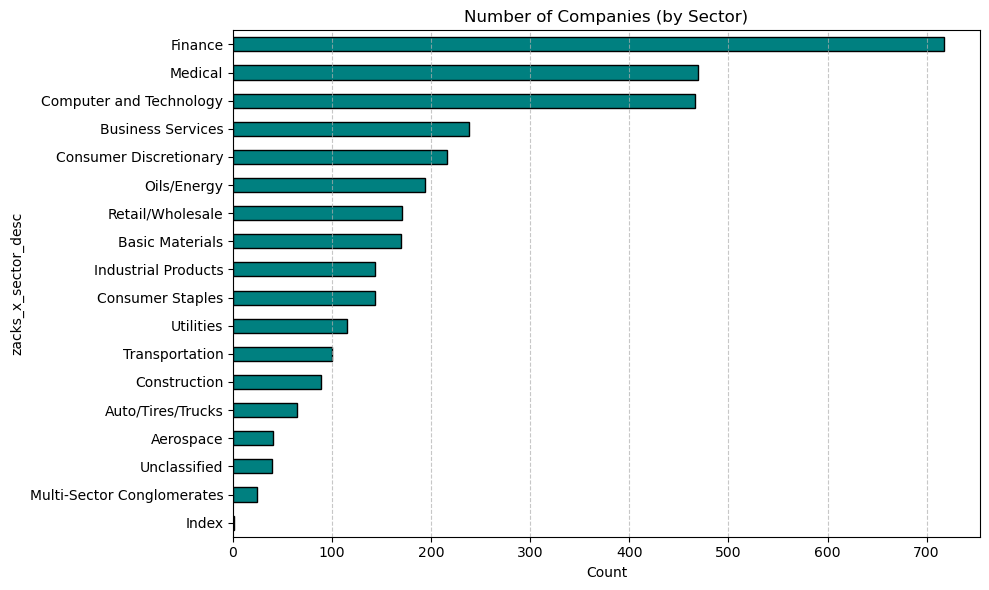

In [9]:
sector_counts_unique = df_unique['zacks_x_sector_desc'].value_counts()

plt.figure(figsize=(10, 6))
sector_counts_unique.plot(kind='barh', color='teal', edgecolor='black')

plt.title('Number of Companies (by Sector)')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Companies (by Sector) 
We can observe a number of companies belonging to the financial, automotive, or insurance sectors. These will need to be removed from our analysis. 

In [10]:
# Define keyword pattern to exclude -- 'Auto' covers "Automotive" -- 'Financ' covers "Finance", "Financial" -- 'Insur' covers "Insurance"
exclude_pattern = "Auto|Financ|Insur"

# Apply the filter using str.contains
# The tilde (~) means "NOT", so we keep rows that DO NOT contain the pattern
df_final = df_final[~df_final['zacks_x_sector_desc'].str.contains(exclude_pattern, case=False, na=False)].copy()
df_final.reset_index(drop=True, inplace=True)

print(f"Rows remaining: {len(df_final)}")
df_unique = df_final.drop_duplicates(subset=['ticker'])
print(f"Remaining Companies: {len(df_unique)}")

Rows remaining: 70685
Remaining Companies: 2618


In [11]:
sector_counts_unique = df_unique['zacks_x_sector_desc'].value_counts()
sector_table = sector_counts_unique.reset_index()

sector_table.columns = ['Sector', 'Count']
total_tickers = sector_table['Count'].sum() 
sector_table['Percentage'] = (sector_table['Count'] / total_tickers) * 100 # Add a Percentage Column

print(sector_table.to_markdown(index=False, floatfmt=".1f")) # Display formatted Table in Jupyter 

| Sector                     |   Count |   Percentage |
|:---------------------------|--------:|-------------:|
| Medical                    |     469 |         17.9 |
| Computer and Technology    |     466 |         17.8 |
| Business Services          |     238 |          9.1 |
| Consumer Discretionary     |     216 |          8.3 |
| Oils/Energy                |     194 |          7.4 |
| Retail/Wholesale           |     171 |          6.5 |
| Basic Materials            |     170 |          6.5 |
| Industrial Products        |     143 |          5.5 |
| Consumer Staples           |     143 |          5.5 |
| Utilities                  |     115 |          4.4 |
| Transportation             |     100 |          3.8 |
| Construction               |      89 |          3.4 |
| Aerospace                  |      40 |          1.5 |
| Unclassified               |      39 |          1.5 |
| Multi-Sector Conglomerates |      24 |          0.9 |
| Index                      |       1 |        

We have successfully **filtered for our target sectors down to 2,618 companies.** 

**Now we must ensure full period coverage.** Each stock should have approximately 1,380 adjusted closing prices (approx. 5.5 years x 252 trading days) over the entirety of our analysis period. 

In [12]:
# I've cached the stock price data from 'PRICES_20241105.zip' into a Parquet file to reduce processing time 
df_prices = pd.read_parquet(r"C:\Users\under\OneDrive\FINM\prices.parquet") # loads data into Pandas DataFrame

In [13]:
valid_tickers = df_unique['ticker'].unique() # tickers for our target 2,618 companies 

# Filter for the specific Date Range
start_date = '2017-12-31' # captures analysis start date
end_date = '2023-06-30'

mask_date = (df_prices['date'] >= start_date) & (df_prices['date'] <= end_date)
df_prices = df_prices[mask_date] 

# Filter DataFrame for desired tickers 
df_prices = df_prices[df_prices['ticker'].isin(valid_tickers)]

In [14]:
ticker_counts = df_prices.groupby('ticker')['date'].count()

# Determine the 'Gold Standard' (Max days any stock has), handling holidays automatically. If the maximum is 1383, that's our target.
max_days = ticker_counts.max()
print(f"Maximum trading days found in this period: {max_days}")

Maximum trading days found in this period: 1383


In [15]:
threshold = max_days * 1 # Filter: keep companies that have data over the ENTIRE period (all 1,383 days) 
complete_tickers = ticker_counts[ticker_counts >= threshold].index
print(f"Companies with complete stock price history: {len(complete_tickers)}")

Companies with complete stock price history: 1571


In [16]:
df_complete = df_unique[df_unique['ticker'].isin(complete_tickers)].copy()
df_complete.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1571 entries, 0 to 70658
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ticker               1571 non-null   object        
 1   m_ticker             1571 non-null   object        
 2   comp_name            1571 non-null   object        
 3   fye                  1571 non-null   int64         
 4   per_type             1571 non-null   object        
 5   per_end_date         1571 non-null   datetime64[ns]
 6   active_ticker_flag   1571 non-null   object        
 7   mkt_val              1552 non-null   float64       
 8   ep_val               176 non-null    float64       
 9   zacks_x_ind_code     1571 non-null   float64       
 10  zacks_x_ind_desc     1571 non-null   object        
 11  zacks_x_sector_code  1571 non-null   float64       
 12  zacks_x_sector_desc  1571 non-null   object        
 13  zacks_m_ind_code     1571 non-null   

We have further **filtered down to 1,571 companies with full period price coverage.** 
* These companies also meet our target sector requirements and have market values which never drop below $100MM during our analysis.
* Our 'df_complete' DataFrame contains these 1,571 stocks, and their sector/industry descriptions -- we have not yet incorporated their prices over the analysis period. 

## Financial Ratios 
We next import the **FR (Financial Ratio)** file which contains pre-calculated financial ratios (such as P/E, ROI, and Debt-to-Equity). 

We will ensure all stocks have a **feasible calculation of the financial ratios specified** earlier AND that they have a **debt/market cap ratio of greater than 0.1** at some point in our analysis period.   

In [17]:
fr_df = pd.read_csv('FR.csv', low_memory = False) # store data into DataFrame 
fr_df['per_end_date'] = pd.to_datetime(fr_df['per_end_date']) # convert column to datetime 

In [18]:
fratio_df = fr_df[fr_df['per_end_date'] > '2017-3-31'].copy() # Filter for our desired date range --> allowing for 9 months of buffer 

We apply a filter to the 'tot_debt_tot_equity' column to find tickers whose stock exceeded a ratio of 0.1 at some point in our target period. 
* Note we use Book Equity as a proxy for Market Capitalization above. These are NOT equivalent.
* We manually calculate the true Debt-to-Market Cap ratio further in our analysis. 

In [19]:
tickers_debt = fratio_df.loc[fratio_df['tot_debt_tot_equity'] > 0.1, 'ticker'].unique() # filter for 'tot_debt_tot_equity' column greater than 0.1
len(tickers_debt) # check number of companies 

8035

8,035 companies employed debt at requisite levels (debt/total equity ratio greater than 0.1 at some point) 

In [20]:
recency_cutoff = '2022-06-30' # 1 year prior to the end date, remove tickers > 6.5 years old 
tickers_recent = fratio_df.loc[fratio_df['per_end_date'] >= recency_cutoff, 'ticker'].unique()

In [21]:
tickers_roi = fratio_df.loc[fratio_df['ret_invst'].notna(), 'ticker'].unique() # tickers with valid calculation of ROI 
len(tickers_roi)

10448

10,448 tickers had feasible calculation of ROI. We next combine all three criteria to filter down this list of stocks. 

In [22]:
valid_tickers = set(tickers_recent) & set(tickers_debt) & set(tickers_roi)
print(f"Original Tickers: {fratio_df['ticker'].nunique()}")
print(f"Valid Tickers meeting all criteria: {len(valid_tickers)}")

Original Tickers: 10906
Valid Tickers meeting all criteria: 6356


In [23]:
fr_final = fratio_df[fratio_df['ticker'].isin(valid_tickers)].copy() 

# Sort for cleanliness
fr_final = fr_final.sort_values(by=['ticker', 'per_end_date'])

valid_financial_tickers = fr_final['ticker'].unique()
df_gold_standard = df_complete[df_complete['ticker'].isin(valid_financial_tickers)].copy() # filter original dataframe

print(f"Total companies: {len(df_gold_standard)}") # Check number of companies 

Total companies: 1404


We combined our earlier list (1,571 companies) and **further filtered down to 1,404 companies** who employed debt at the requisite levels and had a feasible calculation of ROI.

While the FR (Financial Ratios) file contains our required metrics, these data items are often only reported quarterly or annually. However, as the equity prices change daily, each ratio should change accordingly. We will manually produce each ratio in the following section. 

## Price-to-Earnings

In [24]:
# Filter our stock prices DataFrame to companies meeting our target criteria 
valid_tickers = df_gold_standard['ticker'].unique()
df_daily = df_prices[df_prices['ticker'].isin(valid_tickers)].copy()

df_daily['date'] = pd.to_datetime(df_daily['date']) # Ensure dates are datetime objects and sort (Required for merge_asof)
df_daily = df_daily.sort_values(by='date')

In [25]:
# Prepare Financials (fr_final) --> using the filtered financials from our previous step
fr_final['per_end_date'] = pd.to_datetime(fr_final['per_end_date'])
fr_final = fr_final.sort_values(by='per_end_date')

# Select only necessary columns to keep the merge clean
cols_needed = ['ticker', 'per_end_date', 'tot_debt_tot_equity', 
               'ret_invst', 'ret_equity', 'book_val_per_share']

fr_subset = fr_final[cols_needed].copy()

We use the **FC (Fundamentals Condensed)** file to extract earnings per share (EPS) data. 

The **SHRC (Shares Outstanding)** file contains historical share count data, which we will need for calculating per-share metrics. 

In [26]:
# Load FC (Financials) - For EPS
fc_df = pd.read_csv('FC.csv', usecols=['ticker', 'per_end_date', 'eps_diluted_net', 'basic_net_eps','net_lterm_debt','tot_lterm_debt','filing_date'], low_memory=False)
fc_df['per_end_date'] = pd.to_datetime(fc_df['per_end_date'])
fc_df = fc_df.sort_values('per_end_date')

In [27]:
# Load SHRS (Shares) - For Market Cap
shrs_df = pd.read_csv('SHRS.csv', usecols=['ticker', 'per_end_date', 'shares_out'])
shrs_df['per_end_date'] = pd.to_datetime(shrs_df['per_end_date'])
shrs_df = shrs_df.sort_values('per_end_date')

In [28]:
# Filter both to just our 1,404 remaining companies --> save memory
valid_tickers = df_gold_standard['ticker'].unique()
fc_df = fc_df[fc_df['ticker'].isin(valid_tickers)]
shrs_df = shrs_df[shrs_df['ticker'].isin(valid_tickers)]

The below "As-of" merge **matches every daily price with most recent financial report** available as of that day.

Because financial reports are often dated on weekends or holidays (e.g., December 31st), there is often no trading price for that exact day.

The code using pd.merge_asof(..., direction='backward') handles this automatically. It tells Python: "If you can't find a price for Dec 31, give me the price from the closest valid trading day before it (e.g., Dec 29)." **This effectively forward-fills the Friday price to the Saturday/Sunday report date.**

In [29]:
# MERGE 1: Add Share Count (SHRS) 
df_merged = pd.merge_asof(
    df_daily,
    shrs_df,
    left_on='date',
    right_on='per_end_date',
    by='ticker',
    direction='backward'
)

# MERGE 2: Add Earnings (FC) -- matches daily price with the most recent financial quarter end
df_merged = pd.merge_asof(
    df_merged,
    fc_df,
    left_on='date',
    right_on='per_end_date',
    by='ticker',
    direction='backward',
    tolerance=pd.Timedelta(days=180) # Ensure data isn't > 6 months old
)

# MERGE 3: Add Financial Ratios (FR) 
df_merged = pd.merge_asof(
    df_merged,
    fr_subset,
    left_on='date',
    right_on='per_end_date',
    by='ticker',
    direction='backward',
    tolerance=pd.Timedelta(days=180) # Ensure data isn't > 6 months old
)

In [30]:
df_merged.head(2) # quick look at first few rows 

,ticker,date,open,high,low,close,volume,dividend,split,adj_open,...,filing_date,basic_net_eps,tot_lterm_debt,net_lterm_debt,eps_diluted_net,per_end_date,tot_debt_tot_equity,ret_invst,ret_equity,book_val_per_share
0,GHC,2018-01-02,561.7,564.55,559.825,562.95,18391.0,0.0,1.0,522.495124,...,2018-02-23,54.24,486.561,-7.715,53.89,2017-12-31,0.1692,8.8923,10.3765,529.6412
1,SKYW,2018-01-02,53.1,53.30,52.725,53.00,360992.0,0.0,1.0,51.979128,...,2018-02-26,5.60,2377.346,141.419,5.47,2017-12-31,1.5317,7.0172,16.5265,33.8967


We have combined our Financial Ratios, Shares Outstanding, and Stock Price data into a single DataFrame (above). 

Now we proceed to **Price-to-Earnings (P/E) calculation**. 

In [31]:
# Step 1: Select the best EPS (Diluted first, then fills NaN values with Basic version)
df_merged['eps_final'] = df_merged['eps_diluted_net'].fillna(df_merged['basic_net_eps'])

# Step 2: Apply the "Negative Earnings" rule
# "Treat negative earnings per share as 0.001"
df_merged['eps_final'] = df_merged['eps_final'].apply(lambda x: 0.001 if x <= 0 else x)

# Step 3: Calculate P/E
# Price / EPS
df_merged['pe_ratio'] = df_merged['adj_close'] / df_merged['eps_final']

We previously used 'tot_debt_tot_equity' as a proxy for Debt to Market Capitalization. 
* This treated market capitalization and book equity as equivalent, which was acceptable to identify which companies employed sufficient leverage. 

We will now manually calculate true **Debt to Market Capitalization** to double-check our findings: 

In [32]:
# Formula: Total Debt / Market Cap
df_merged['tot_lterm_debt'] = df_merged['tot_lterm_debt'].fillna(0.0) #

# Step 1: Calculate Market Cap (Price * Shares)
df_merged = df_merged.dropna(subset=['shares_out']) 
df_merged['market_cap'] = df_merged['adj_close'] * df_merged['shares_out']

# Step 2: Calculate Total Debt
df_merged['debt_to_mkt_cap'] = df_merged['tot_lterm_debt'] / df_merged['market_cap']

In [33]:
#  Replace Infinite values with NaN (Infinite happens if Market Cap or Earnings are 0)
df_merged.replace([np.inf, -np.inf], np.nan, inplace=True)

final_cols = [
    'ticker', 'date', 'adj_close', 'market_cap', 
    'pe_ratio', 'debt_to_mkt_cap'
]
df_final_model = df_merged[final_cols].copy()

Is the true Debt/Market Cap ratio is greater than 0.1 somewhere in the period Jan 2018 through Jun 2023? 
* We apply a more stringent filter, requiring Debt/Market Cap to be greater than 0.1, rather than Debt to Book Equity. 


In [34]:
max_debt_ratio = df_final_model.groupby('ticker')['debt_to_mkt_cap'].max()

# Get the list of tickers that hit the 0.1 mark at least once
valid_tickers_mkt = max_debt_ratio[max_debt_ratio > 0.1].index

print(f"Tickers passing Debt/MktCap > 0.1: {len(valid_tickers_mkt)}")

Tickers passing Debt/MktCap > 0.1: 1267


In [35]:
# Filter the dataframe
df_final_verified = df_final_model[df_final_model['ticker'].isin(valid_tickers_mkt)].copy()

df_final_verified.reset_index(drop=True, inplace=True) # Reset index

In [36]:
df_final_verified['ticker'].nunique()

1267

We further filtered our DataFrame down to 1,267 companies. 

In [37]:
mt_sub = mt_df.iloc[:,[1, 14]]
final_df = pd.merge(df_final_verified, mt_sub, on='ticker', how='left')
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1746747 entries, 0 to 1746746
Data columns (total 7 columns):
 #   Column               Dtype         
---  ------               -----         
 0   ticker               object        
 1   date                 datetime64[ns]
 2   adj_close            float64       
 3   market_cap           float64       
 4   pe_ratio             float64       
 5   debt_to_mkt_cap      float64       
 6   zacks_x_sector_desc  object        
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 93.3+ MB


## Return on Investment (Derived Method) 
Stock prices change very day, but company earnings (Returns) are only reported quarterly. 

We will convert quarterly company earnings into a daily time series using the following formula: 

$V = \frac{R}{D + M}$

Where: 

* $V$ (ROI): Return on Investment (from the report) -- based on FR/ret_invst

* $M$ (Market Cap): company value (price x shares) 

* $D$ (Debt): debt of the company (assumed fixed between reports)

* $R$ (Return): implied earnings (unknown constant)

We will calculate fixed Debt ($D_{fixed}$) and implied Return ($R_{fixed}$) using data available at "snapshot" moment of the report end date.

In [38]:
# "Report Snapshot" dataframe uses Ticker, Date, Reported ROI (V), Debt/Equity, and Book Value
cols_ratios = ['ticker', 'per_end_date', 'ret_invst', 'tot_debt_tot_equity', 'book_val_per_share']
df_ratios_subset = fratio_df[cols_ratios].copy()

cols_dates = ['ticker', 'per_end_date', 'filing_date']
df_dates_subset = fc_df[cols_dates].copy()

# Ensure datetime types for safe merging
df_ratios_subset['per_end_date'] = pd.to_datetime(df_ratios_subset['per_end_date'])
df_dates_subset['per_end_date'] = pd.to_datetime(df_dates_subset['per_end_date'])
df_dates_subset['filing_date'] = pd.to_datetime(df_dates_subset['filing_date'])

# Merge --> use an inner merge to ensure we only keep reports where we have both data AND a filing date
df_reports = pd.merge(
    df_ratios_subset,
    df_dates_subset,
    on=['ticker', 'per_end_date'],
    how='inner'
)

# Sort strictly by filing_date 
df_reports = df_reports.sort_values('filing_date')

A crucial part of this process is **avoiding "look-ahead" bias.** 

We cannot use information before it is publicly released. 
* The pd.merge_asof function is used to merge the calculated constants onto the daily price data (final_df).
* The merge left_on='date', right_on='filing_date': ensures that the new constants ($R$ and $D$) are only applied to days after the company actually filed its financials. 

In [39]:
# Add "Shares Outstanding" at the time of the report 
df_reports = df_reports.sort_values('per_end_date')
shrs_df = shrs_df.sort_values('per_end_date')

df_reports = pd.merge_asof(
    df_reports,
    shrs_df[['ticker', 'per_end_date', 'shares_out']],
    on='per_end_date',
    by='ticker',
    direction='backward'
)

In [40]:
# Add "Stock Price" at the time of the report
price_lookup = df_prices[['ticker', 'date', 'adj_close']].sort_values('date')

# Force conversion to datetime for both dataframes --> errors='coerce' turns unreadable dates into NaT so the code doesn't crash
df_reports['per_end_date'] = pd.to_datetime(df_reports['per_end_date'], errors='coerce')
price_lookup['date'] = pd.to_datetime(price_lookup['date'], errors='coerce')

# Sort by date 
df_reports = df_reports.sort_values('per_end_date')
price_lookup = price_lookup.sort_values('date')

df_reports = pd.merge_asof(
    df_reports,
    price_lookup,
    left_on='per_end_date',
    right_on='date',
    by='ticker',
    direction='backward'
)

In [41]:
# Calculate the Fixed Components (D and R)

# Fixed Debt (D) = Debt/Equity * Book_Val_Per_Share * Shares
df_reports['D_fixed'] = (df_reports['tot_debt_tot_equity'] * df_reports['book_val_per_share']) * df_reports['shares_out']

# Snapshot Market Cap (M_snapshot) = Price_at_Report * Shares_at_Report
df_reports['M_snapshot'] = df_reports['adj_close'] * df_reports['shares_out']

# Implied Return (R)
# Formula: R = V * (D + M)
df_reports['R_fixed'] = df_reports['ret_invst'] * (df_reports['D_fixed'] + df_reports['M_snapshot'])

# Clean up
df_reports = df_reports.dropna(subset=['R_fixed', 'D_fixed'])

print(f"Calculated Constants for {len(df_reports)} quarterly reports.")

Calculated Constants for 49454 quarterly reports.


Once the daily dataframe has the constants populated, we calculate the final metric: 

$V_{daily} = \frac{R_{fixed}}{D_{fixed} + M_{daily}}$

* $R_{fixed}$  stays constant until the next filing.
* $D_{fixed}$  stays constant until the next filing.
* $M_{daily}$  changes daily as it is driven by the daily stock price. 

In [42]:
# Merge Constants to Daily Data
cols_to_merge = ['ticker', 'per_end_date', 'filing_date', 'R_fixed', 'D_fixed']
reports_subset = df_reports[cols_to_merge].sort_values('filing_date')

reports_subset = df_reports[cols_to_merge].dropna(subset=['filing_date']).sort_values('filing_date') # Drop rows where filing_date is NaN, then sort

df_dynamic = pd.merge_asof(
    final_df.sort_values('date'),
    reports_subset,
    left_on='date',
    right_on='filing_date', # We did not know these numbers until FC/filing date 
    by='ticker',
    direction='backward',
    tolerance=pd.Timedelta(days=180)
)

# List of columns that are breaking the model
cols_to_fix = ['per_end_date', 'R_fixed', 'D_fixed']

# Backfill these specific columns per ticker
# This takes the values from ~Jan 31 and copies them backward to Jan 1-30
df_dynamic[cols_to_fix] = df_dynamic.groupby('ticker')[cols_to_fix].bfill()

# Step Calculate Dynamic Daily ROI (V_t) 
# V_t = R_fixed / (D_fixed + Market_Cap_Daily)
df_dynamic['V_daily'] = df_dynamic['R_fixed'] / (df_dynamic['D_fixed'] + df_dynamic['market_cap'])

In [43]:
df_dynamic.head(3)

,ticker,date,adj_close,market_cap,pe_ratio,debt_to_mkt_cap,zacks_x_sector_desc,per_end_date,filing_date,R_fixed,D_fixed,V_daily
0,GHC,2018-01-02,523.657878,2880.118330,9.717162,0.168938,Consumer Discretionary,2018-03-31,NaT,5195.116086,510.264979,1.532309
1,LNG,2018-01-02,53.025742,12602.097938,53025.742395,2.010459,Oils/Energy,2018-03-31,NaT,83263.548732,25649.626823,2.176727
2,PSX,2018-01-02,77.941715,39867.966539,7.912864,0.252559,Oils/Energy,2018-03-31,NaT,75180.394331,11620.341738,1.460145


In [44]:
df_dynamic.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1746747 entries, 0 to 1746746
Data columns (total 12 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   ticker               1746747 non-null  object        
 1   date                 1746747 non-null  datetime64[ns]
 2   adj_close            1746747 non-null  float64       
 3   market_cap           1746747 non-null  float64       
 4   pe_ratio             1725358 non-null  float64       
 5   debt_to_mkt_cap      1746747 non-null  float64       
 6   zacks_x_sector_desc  1746747 non-null  object        
 7   per_end_date         1733861 non-null  datetime64[ns]
 8   filing_date          1458068 non-null  datetime64[ns]
 9   R_fixed              1733861 non-null  float64       
 10  D_fixed              1733861 non-null  float64       
 11  V_daily              1733861 non-null  float64       
dtypes: datetime64[ns](3), float64(7), object(2)
memory usage

We can observe a number of null values in the V_daily column (our dynamic daily ROI). These companies have price data, but lack matches in our financial report data. These rows represent less than 1% of our data. 

We will remove these rows where V_daily was calculated as NaN (due to missing reports). 

In [45]:
 df_final_dynamic = df_dynamic.dropna(subset=['V_daily']).copy() # drop rows with NaN values. 

# Select only the clean columns for the final file --> drop the intermediate calculation columns (R_fixed, D_fixed, per_end_date) to keep clean 
cols_to_keep = [
    'ticker', 'date', 'zacks_x_sector_desc', 
    'adj_close', 'market_cap', 
    'pe_ratio', 'debt_to_mkt_cap', 'V_daily', 
]

# final verification 
df_master = df_final_dynamic[cols_to_keep].copy()
df_master.reset_index(drop=True, inplace=True) 

In [46]:
ticker_counts = df_master.groupby('ticker')['pe_ratio'].count()

# Confirm number of trading days. 
max_days = ticker_counts.max()
print(f"Target Trading Days: {max_days}")

Target Trading Days: 1383


In [47]:
# Identify tickers that are missing P/E data (have fewer than max_days) --> applies 95% tolerance threshold
valid_tickers = ticker_counts[ticker_counts >= (max_days * 0.95)].index

# Filter the dataset to keep ONLY those valid tickers
df_repaired = df_master[df_master['ticker'].isin(valid_tickers)].copy()

# Forward fill any tiny remaining gaps (1-2 days)
df_repaired['pe_ratio'] = df_repaired.groupby('ticker')['pe_ratio'].ffill()
# Backfill to fix missing values at the START of the series
df_repaired['pe_ratio'] = df_repaired.groupby('ticker')['pe_ratio'].bfill()

print(f"Investable Universe:    {df_repaired['ticker'].nunique()}")

Investable Universe:    1193


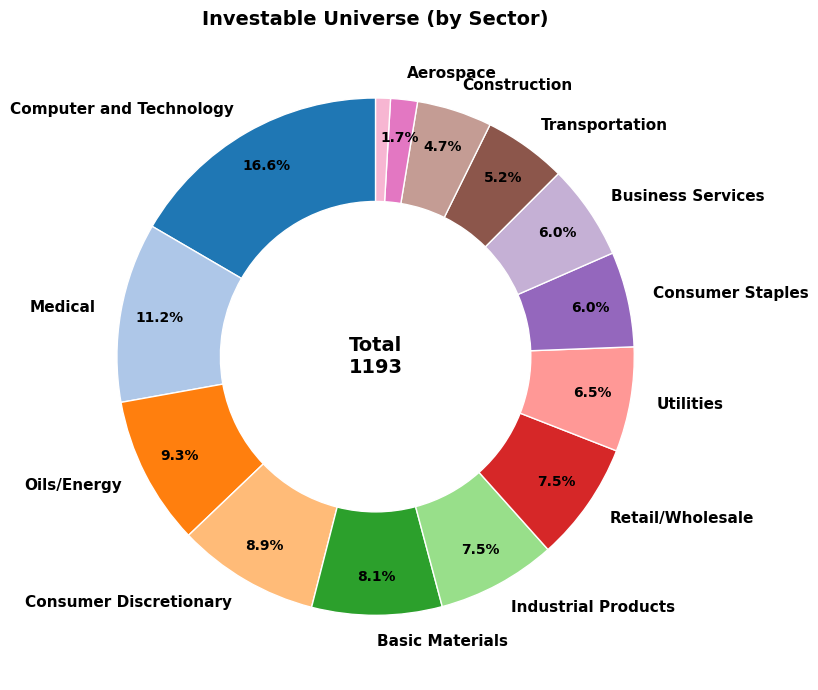

In [48]:
df_unique_1 = df_repaired.drop_duplicates(subset=['ticker']) # 1. Prepare Data
sector_counts = df_unique_1['zacks_x_sector_desc'].value_counts()
total = sector_counts.sum()

# Filter Labels Logic (Hide label if < 5%)
filtered_labels = [
    sector if (count / total > 0.01) else '' 
    for sector, count in zip(sector_counts.index, sector_counts)
]
# Function hides label if percentage is less than 3% 
def make_autopct(pct): 
    return ('%1.1f%%' % pct) if pct > 1 else ''
    
# Define Colors
colors = sns.color_palette('tab20')[0:len(sector_counts)]

plt.figure(figsize=(11, 7))

# Create Donut Chart
wedges, texts, autotexts = plt.pie(
    sector_counts,
    labels=filtered_labels,
    autopct=make_autopct,
    startangle=90,
    colors=colors,
    pctdistance=0.85,
    labeldistance=1.1,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=1)
)

# Polish Text
for text in texts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight("bold")

# Add Center Title
plt.text(0, 0, f'Total\n{len(df_unique_1)}', ha='center', va='center', fontsize=14, fontweight='bold')

plt.title('Investable Universe (by Sector)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## The Investable Universe 
We have successfully refined our dataset to a **final investable universe of 1,193 companies** that satisfy all six of our specified criteria.

# 2. Quantile Trading Strategy 

## Winsorization
We first limit the influence of extreme outliers (e.g., a P/E ratio of 5,000 due to minimal earnings) by winsorizing the financial ratios at the 1st and 99th percentiles. 

* This preserves the rank order of our data while preventing statistical distortions.

* We then normalize the winsorized factors by calculating the Z-score for each stock relative to the cross-sectional mean and standard deviation of that month.

In [49]:
# Winsorization function 
def winsorize_series(s, lower = 0.01, upper = 0.99): 
    low_val = s.quantile(lower)
    high_val = s.quantile(upper)
    return s.clip(lower=low_val, upper=high_val)

# We create a new dataframe for signals to keep things clean
df_signals = df_repaired.copy()
cols_to_fix = ['pe_ratio', 'debt_to_mkt_cap', 'V_daily']

for col in cols_to_fix:
    df_signals[col] = winsorize_series(df_signals[col])

## Z-Score Normalization 
We normalize the winsorized factors by calculating the Z-score for each stock relative to the cross-sectional mean and standard deviation of that day. 

In [50]:
# We group by DATE to ensure we rank relative to peers at that specific moment
# (Avoids look-ahead bias or inflation bias)

def zscore(x):
    return (x - x.mean()) / x.std()

# Calculate Cross-Sectional Z-Scores
df_signals['z_pe'] = df_signals.groupby('date')['pe_ratio'].transform(zscore)
df_signals['z_debt'] = df_signals.groupby('date')['debt_to_mkt_cap'].transform(zscore)
df_signals['z_roi'] = df_signals.groupby('date')['V_daily'].transform(zscore)

## Feature Engineering (Signals)

We will first test individual factors (D/M, ROI, P/E) before constructing a blended "composite" score. 

Single-Factor Signals: 
* Return on Investment (Quality) -->  target High ROI
* Price-to-Earnings Ratio (Value) -->  target Low P/E
* Debt/Market Cap (Safety) --> target Low Debt (initially)

We have successfully added columns with Z-score values for P/E, Debt, and ROI. 

Before we begin our strategy testing, we'll want to import rolling 3-month LIBOR/SOFR data to simulate the portfolio's variable funding rate. 

## Portfolio Funding (Rolling 3-Month LIBOR/SOFR)

In [51]:
df_rates = pd.read_csv('LIBOR_SOFR.tab', sep='\t')

In [52]:
df_rates.columns = ['Date', '3M LIBOR/SOFR']
df_rates['Date'] = pd.to_datetime(df_rates['Date'])
df_rates['3M LIBOR/SOFR'] = df_rates['3M LIBOR/SOFR'] / 100.0 # scale to percentage terms <-- run this cell just once 
df_rates.set_index('Date', inplace=True) # Set date as index for easy lookup later

In [53]:
# Handle Missing Data (Forward Fill)
# Interest rates don't change every day. If a day is missing (e.g., holiday), we assume the rate is the same as the previous day.
df_rates['3M LIBOR/SOFR'] = df_rates['3M LIBOR/SOFR'].ffill()

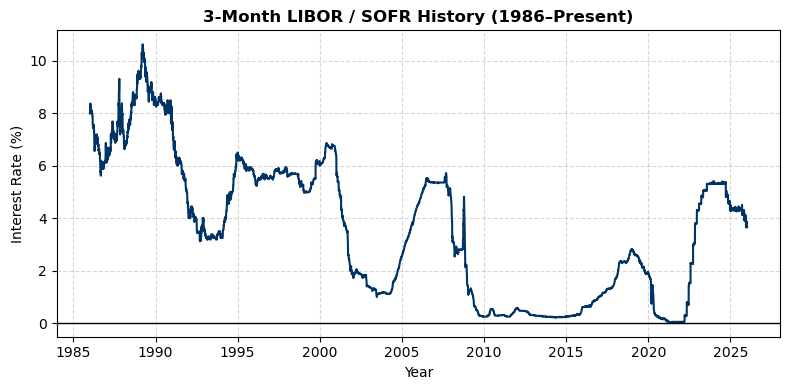

In [54]:
plt.figure(figsize=(8, 4))

plt.plot(df_rates.index, df_rates['3M LIBOR/SOFR'] * 100, color='#003366', linewidth=1.5) # Plot the rate (multiplying by 100 to show as %)

# Formatting
plt.title('3-Month LIBOR / SOFR History (1986–Present)', fontsize=12, fontweight='bold')
plt.ylabel('Interest Rate (%)', fontsize=10)
plt.xlabel('Year', fontsize=10)

# Grid and Style
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(0, color='black', linewidth=1)

# Format x-axis to show years clearly
plt.gca().xaxis.set_major_locator(mdates.YearLocator(5)) # Every 5 years
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

## Strategy Backtesting Function

**Rebalancing Frequency:** Monthly (End of Month), using last available adjusted closing price. 

**Portfolio Construction:** Long (Top Quantile by signal rank) / Short (Bottom Quantile by signal rank) 

**Gross Notional:** Fixed at $2MM per period

**Initial Capital:** 10x Gross Notional ($20MM) 

**Funding:** Uninvested cash earns the monthly Risk-Free Rate derived from historical 3M LIBOR/SOFR.
* Short proceeds earn a rebate rate of Rf - 100bps, accounting for stock borrow costs. 

**Flexibility:** Our function supports variable quantile sorting (set n_quantiles = 10, 5, etc.) 

In [55]:
def run_strategy(df, signal_col, rates_df, ascending=True, capital_ratio=10.0, n_quantiles=10):
   
    # Resample to Monthly
    df_monthly = df.groupby(['ticker', pd.Grouper(key='date', freq='ME')]).last().reset_index()
    rebalance_dates = sorted(df_monthly['date'].unique())
    portfolio_stats = []
    
    threshold = 1.0 / n_quantiles # variable quantile sorting 
    
    # Capital Setup
    target_long_notional = 1_000_000 # 1M (Long) 
    target_short_notional = 1_000_000 # 1M (Short) 
    initial_capital = (target_long_notional + target_short_notional) * capital_ratio # initial capital is 10x Gross Notional 
    current_capital = initial_capital
    
    for i in range(len(rebalance_dates) - 1):
        curr_date = rebalance_dates[i]
        next_date = rebalance_dates[i+1]
        
        # Dynamic rate lookup - obtains risk-free rate for a specific month
        # .asof() finds the closest date if the exact date is missing 
        try:
            r_f = rates_df.asof(curr_date)['rate']
        except:
            # Fallback if date is out of range 
            r_f = 0.04 
            
        period_data = df_monthly[df_monthly['date'] == curr_date].copy()
        
        # --- Selection Logic (Same as before) ---
        if len(period_data) < (n_quantiles * 2): continue
            
        period_data['pct_rank'] = period_data[signal_col].rank(pct=True, method='first')
        
        if ascending:
            longs = period_data[period_data['pct_rank'] <= threshold]
            shorts = period_data[period_data['pct_rank'] >= (1.0 - threshold)]
        else:
            longs = period_data[period_data['pct_rank'] >= (1.0 - threshold)]
            shorts = period_data[period_data['pct_rank'] <= threshold]
            
        # Returns 
        next_period_data = df_monthly[df_monthly['date'] == next_date].set_index('ticker')
        
        # Helper function for returns
        def get_ret(tickers):
            rets = []
            for t in tickers:
                if t in next_period_data.index:
                    p0 = period_data.loc[period_data['ticker']==t, 'adj_close'].values[0]
                    p1 = next_period_data.loc[t, 'adj_close']
                    rets.append((p1/p0) - 1)
            return np.mean(rets) if rets else 0.0

        avg_long_ret = get_ret(longs['ticker'])
        avg_short_ret = get_ret(shorts['ticker'])
        
        dt = 1/12 
        
        # Dynamic PL calculation 
        long_pl = target_long_notional * avg_long_ret
        short_pl = target_short_notional * (-1 * avg_short_ret)
        
        # Repo Rate varies with risk free rate 
        # Repo = RiskFree - 100 bps 
        repo_rate = r_f - 0.01
        short_rebate = target_short_notional * repo_rate * dt
        
        # Interest on Uninvested Capital varies with risk free rate 
        interest_income = (current_capital - target_long_notional) * r_f * dt
        
        total_pl = long_pl + short_pl + short_rebate + interest_income
        current_capital += total_pl
        
        portfolio_stats.append({
            'date': next_date,
            'total_pl': total_pl,
            'capital': current_capital,
            'long_ret': avg_long_ret,
            'short_ret': avg_short_ret,
            'risk_free_rate': r_f  
        })
        
    return pd.DataFrame(portfolio_stats)

## Performance Metrics
The function below assesses risk-adjusted performance, tail risk, and capital efficiency through the following metrics: 

### Risk-Adjusted Returns 

**Dynamic Sharpe Ratio**: Calculated as annualized excess return over monthly realized Risk-Free Rate, normalized by annualized volatility. 
* Sharpe = $\frac{{R_p - R_f}}{\sigma_p}$

**Sortino Ratio**: Modification of Sharpe ratio which penalizes downside volatility. 

### Tail Metrics & Maximum Drawdown 

**Maximum Drawdown (MDD)**: The largest top-to-bottom decline in totoal capital --> worst-case scenario for investor buying at the peak.

**Value at Risk (VaR 95%)**: Return threshold at the 5th percentile. In 95% of months, losses will not exceed this figure.

**Conditional Value at Risk (CVaR)**: Average loss incurred only during the worst 5% of months.

### Capital Efficiency 

Total portfolio returns may be distorted by the large cash buffer held as margin. To isolate each signal's contribution, we calculate **"Pure Return"** or **Return on Gross Traded Notional.**

In [56]:
def calc_metrics(res_df, strategy_name):
    # 1. Prepare Returns
    res_df['pct_ret'] = res_df['total_pl'] / res_df['capital'].shift(1)
    
    # 2. Pure Strategy Return (PL / Traded Notional)
    # Dynamic Interest subtraction
    interest_est = res_df['capital'].shift(1) * res_df['risk_free_rate'] * (1/12)
    res_df['trading_pl'] = res_df['total_pl'] - interest_est
    
    gross_notional = 2_000_000 
    res_df['pure_ret'] = res_df['trading_pl'] / gross_notional
    
    res_df.dropna(inplace=True)
    
    # --- Standard Metrics ---
    ann_ret = res_df['pct_ret'].mean() * 12
    ann_vol = res_df['pct_ret'].std() * (12**0.5)
    
    excess_ret = res_df['pct_ret'] - (res_df['risk_free_rate'] / 12)
    sharpe = (excess_ret.mean() * 12) / ann_vol if ann_vol > 0 else 0
    
    # --- 1. MAXIMUM DRAWDOWN (MDD) ---
    # Calculate Cumulative Wealth Index
    wealth_index = (1 + res_df['pct_ret']).cumprod()
    # Calculate Previous Peak at every step
    previous_peaks = wealth_index.cummax()
    # Calculate Drawdown
    drawdown = (wealth_index - previous_peaks) / previous_peaks
    max_drawdown = drawdown.min() # The deepest hole (negative number)
    
    # --- 2. TAIL METRICS (VaR & CVaR) ---
    # We use the 5th Percentile (95% Confidence)
    # "In the worst 5% of months, what is the cutoff?"
    var_95 = res_df['pct_ret'].quantile(0.05)
    
    # CVaR (Expected Shortfall)
    # "In the worst 5% of months, what is the average loss?"
    cvar_95 = res_df[res_df['pct_ret'] <= var_95]['pct_ret'].mean()
    
    # --- 3. DOWNSIDE METRICS ---
    # Sortino (Downside Deviation)
    neg_rets = res_df[res_df['pct_ret'] < 0]['pct_ret']
    downside_dev = neg_rets.std() * (12**0.5)
    sortino = (ann_ret - res_df['risk_free_rate'].mean()) / downside_dev if len(neg_rets) > 0 else np.nan

    return {
        'Strategy': strategy_name,
        'Ann Ret (Port)': f"{ann_ret:.2%}",  
        'Ann Vol (Port)': f"{ann_vol:.2%}",   
        'Sharpe': round(sharpe, 2),
        'Sortino': round(sortino, 2),
        'Max Drawdown': f"{max_drawdown:.2%}", # Deepest loss from peak
        'VaR (95%)': f"{var_95:.2%}",          # Worst case month threshold
        'CVaR (95%)': f"{cvar_95:.2%}",        # Avg loss in worst months
        'Pure Ret': f"{(res_df['pure_ret'].mean() * 12):.2%}",
        'Pure Vol': f"{(res_df['pure_ret'].std() * (12**0.5)):.2%}"
    }

# 3. Analysis | Strategy Performance 

In [57]:
# 1. PE Ratio (Low is Good -> Ascending=True)
res_pe = run_strategy(df_signals, 'pe_ratio', rates_df=df_rates, ascending=True, n_quantiles=10)

# 2. Debt/Cap (Low is Good -> Ascending=True)
res_debt = run_strategy(df_signals, 'debt_to_mkt_cap', rates_df=df_rates, ascending=True, n_quantiles=10)

# 3. ROI (High is Good -> Ascending=False)
res_roi = run_strategy(df_signals, 'V_daily', rates_df=df_rates, ascending=False, n_quantiles=10)

In [58]:
# --- Compare Results ---
results = [
    calc_metrics(res_pe, "P/E Ratio"),
    calc_metrics(res_debt, "Debt/Cap"),
    calc_metrics(res_roi, "ROI"),
]

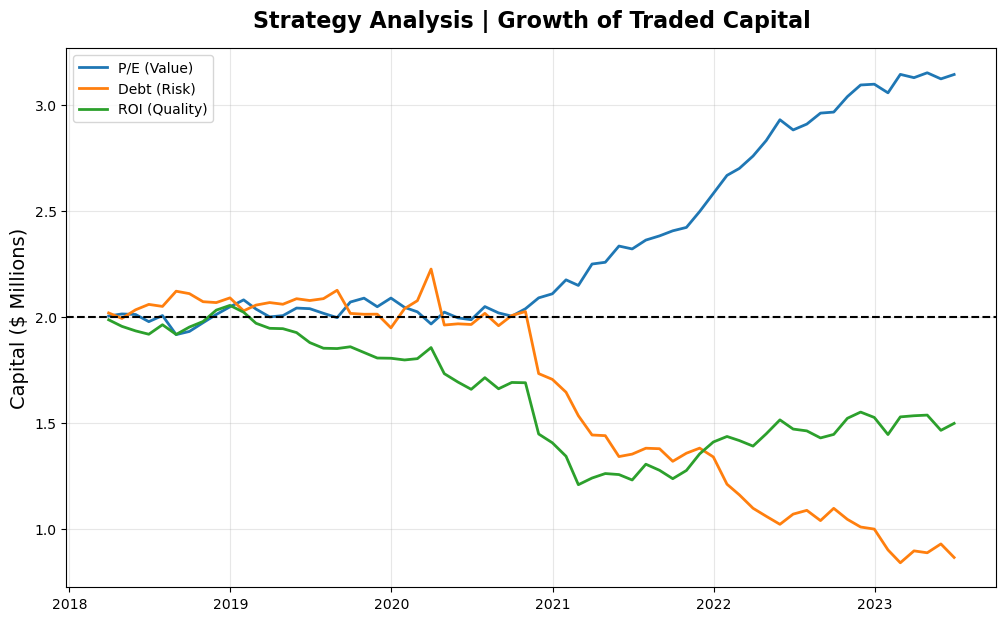

In [59]:
strategies = {
    "P/E (Value)": res_pe,
    "Debt (Risk)": res_debt,
    "ROI (Quality)": res_roi,}

plt.figure(figsize=(12, 7))

for name, df in strategies.items():
    df = df.sort_values('date')
    
    # Calculate Traded Equity (Start at $2M, remove Cash Drag)
    interest_est = df['capital'].shift(1).fillna(20_000_000) * df['risk_free_rate'] * (1/12)
    trading_pl = df['total_pl'] - interest_est
    
    # Cumulative Growth of $2M
    equity_curve = 2_000_000 + trading_pl.cumsum()
    
    plt.plot(df['date'], equity_curve / 1_000_000, label=name, linewidth=2)

plt.title("Strategy Analysis | Growth of Traded Capital", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("Capital ($ Millions)", fontsize=12)
plt.ylabel("Capital ($ Millions)", fontsize=14)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.axhline(2.0, color='black', linestyle='--')

plt.show()

### Single-Factor Analysis 

**Best Strategy:** P/E Ratio (Value) --> Pure Return (+10.73%) 
* Buying cheap stocks and shorting expensive ones was the only standalone strategy that generated positive excess returns.
* "NaN" Sortino ratio -- a positive anomaly. This strategy rarely experienced a negative month.

**Losing Strategy:** Debt/Cap (Safety) --> Negative Pure Return (-10.65%) 
* The strategy of "buying safe, low-debt companies" lost nearly 11% per year relative to the short side.
* The market rewarded leverage and penalized safety in this period. 

In [60]:
pd.DataFrame(results) # Display Results 

,Strategy,Ann Ret (Port),Ann Vol (Port),Sharpe,Sortino,Max Drawdown,VaR (95%),CVaR (95%),Pure Ret,Pure Vol
0,P/E Ratio,4.90%,0.66%,1.37,NaN,-0.11%,0.13%,0.05%,10.73%,7.51%
1,Debt/Cap,3.07%,1.10%,-0.85,-0.74,-0.97%,-0.17%,-0.56%,-10.65%,12.23%
2,ROI,3.55%,0.85%,-0.52,-0.40,-0.86%,0.00%,-0.32%,-4.71%,9.44%


### Composite Signal Analysis
Using what we've learned from our single-factor analysis, we will next **construct a composite signal.**

In [61]:
df_signals['combo_score'] = df_signals['z_debt'] - df_signals['z_pe'] - df_signals['z_roi']  # adds a new column with "combined" score 

$\text{Composite Score} = Z(\text{Debt}) - Z(P/E) - Z(\text{ROI})$

This is essentially a "Distressed Asset" strategy: we buying the worst companies in the market (bad balance sheet, bad margins) betting that they are oversold and will rally harder than quality stocks.
* Given the negative return of the "Low Debt" strategy, we inverted the signal to target High Leverage.
* The P/E Ratio remains a core component due to its robust standalone return (+10.73%).


In [62]:
res_combo = run_strategy(df_signals, 'combo_score', rates_df=df_rates, ascending=False, n_quantiles=10)

In [63]:
results.append(calc_metrics(res_combo, "Combined (High Debt, Low P/E, Low ROI)"))

pd.DataFrame(results) # Display results 

,Strategy,Ann Ret (Port),Ann Vol (Port),Sharpe,Sortino,Max Drawdown,VaR (95%),CVaR (95%),Pure Ret,Pure Vol
0,P/E Ratio,4.90%,0.66%,1.37,NaN,-0.11%,0.13%,0.05%,10.73%,7.51%
1,Debt/Cap,3.07%,1.10%,-0.85,-0.74,-0.97%,-0.17%,-0.56%,-10.65%,12.23%
2,ROI,3.55%,0.85%,-0.52,-0.40,-0.86%,0.00%,-0.32%,-4.71%,9.44%
3,"Combined (High Debt, Low P/E, Low ROI)",4.97%,0.97%,1.00,NaN,-0.19%,0.11%,0.00%,11.30%,10.92%


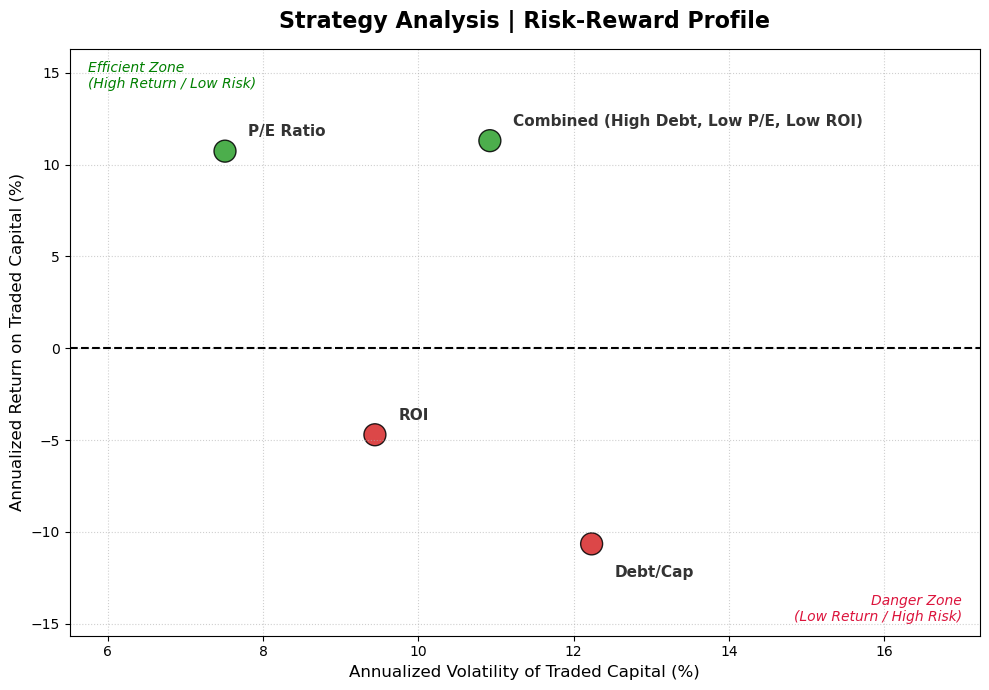

In [64]:
plot_data = pd.DataFrame(results) 

plot_data['Y_Alpha'] = plot_data['Pure Ret'].str.rstrip('%').astype(float) # Convert the string percentages back to floats
plot_data['X_Vol'] = plot_data['Pure Vol'].str.rstrip('%').astype(float)

plt.figure(figsize=(10, 7)) # Setup Plot

# Dynamic Color Logic
# Green for Winners, Red for Losers, Blue for the Combo/Complex strategy
colors = []
for index, row in plot_data.iterrows():
    if row['Y_Alpha'] > 0:
        colors.append('#2ca02c') # Green
    else:
        colors.append('#d62728') # Red

plt.scatter(plot_data['X_Vol'], plot_data['Y_Alpha'], s=250, c=colors, alpha=0.85, edgecolors='black') # Create Scatter Plot

# Automated Labeling
for i in range(len(plot_data)):
    label = plot_data.iloc[i]['Strategy']
    x = plot_data.iloc[i]['X_Vol']
    y = plot_data.iloc[i]['Y_Alpha']
    
    # Push label down if it's the "Debt" strategy to avoid overlap
    y_offset = 0.8
    if "Debt" in label and y < 0:
        y_offset = -1.8
        
    plt.text(x + 0.3, y + y_offset, label, fontsize=11, fontweight='bold', color='#333333')

# Formatting & Quadrants
plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
plt.axvline(0, color='black', linewidth=1.5, linestyle='--')

plt.title('Strategy Analysis | Risk-Reward Profile', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Annualized Volatility of Traded Capital (%)', fontsize=12)
plt.ylabel('Annualized Return on Traded Capital (%)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.xlim(plot_data['X_Vol'].min() - 2, plot_data['X_Vol'].max() + 5) # Adds buffer around your max/min values so dots aren't on the edge
plt.ylim(plot_data['Y_Alpha'].min() - 5, plot_data['Y_Alpha'].max() + 5)

# Annotations
plt.text(0.02, 0.98, "Efficient Zone\n(High Return / Low Risk)", 
         transform=plt.gca().transAxes, 
         fontsize=10, color='green', style='italic', 
         ha='left', va='top')
plt.text(0.98, 0.02, "Danger Zone\n(Low Return / High Risk)", 
         transform=plt.gca().transAxes, 
         fontsize=10, color='crimson', style='italic', 
         ha='right', va='bottom')

plt.tight_layout()
plt.show()

**Above:** By adding the "High Debt", "Low ROI" signals, we increased our Pure Return metric from 10.73% to 11.30%. 
* While we captured more total profit, our Pure Volatility metric spiked from 7.51% to 10.92%.

### The "Change" Ratios 
We introduce **rate-of-change metrics (delta)** to rank based on changes in our ratios rather than the ratios themselves: 
* A low P/E ratio is good, but a falling P/E ratio suggests the stock is becoming cheaper relative to earnings.
* Similarly, we track the 30-day change in ROI (delta_roi) to identify companies with accelerating efficiency.

In [65]:
# Percent change over the last 30 days -- we group by ticker to calculate change over time

df_signals.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace Infinity with NaN

df_signals.sort_values(['ticker', 'date'], inplace=True)

df_signals['delta_pe'] = df_signals.groupby('ticker')['pe_ratio'].pct_change(30)
df_signals['delta_roi'] = df_signals.groupby('ticker')['V_daily'].pct_change(30)

for col in ['delta_pe', 'delta_roi']:
    df_signals[col] = winsorize_series(df_signals[col])

In [66]:
# Run backtests
# Delta P/E --> P/E ratio shrinking (negative change) indicates stock is getting cheaper relative to earnings -- Long stocks with biggest decline 
res_delta_pe = run_strategy(df_signals, 'delta_pe', rates_df=df_rates, ascending=True, n_quantiles=10) 

# Delta ROI --> ROI growing (positive change) indicates accelerating efficiency
res_delta_roi = run_strategy(df_signals, 'delta_roi', rates_df=df_rates, ascending=False, n_quantiles=10)

In [67]:
results.append(calc_metrics(res_delta_pe, "Delta P/E (Multiple Contraction)"))
results.append(calc_metrics(res_delta_roi, "Delta ROI (Improving Quality)"))

# Display Master Table
df_results = pd.DataFrame(results)
df_results

,Strategy,Ann Ret (Port),Ann Vol (Port),Sharpe,Sortino,Max Drawdown,VaR (95%),CVaR (95%),Pure Ret,Pure Vol
0,P/E Ratio,4.90%,0.66%,1.37,NaN,-0.11%,0.13%,0.05%,10.73%,7.51%
1,Debt/Cap,3.07%,1.10%,-0.85,-0.74,-0.97%,-0.17%,-0.56%,-10.65%,12.23%
2,ROI,3.55%,0.85%,-0.52,-0.40,-0.86%,0.00%,-0.32%,-4.71%,9.44%
3,"Combined (High Debt, Low P/E, Low ROI)",4.97%,0.97%,1.00,NaN,-0.19%,0.11%,0.00%,11.30%,10.92%
4,Delta P/E (Multiple Contraction),4.93%,0.55%,1.71,NaN,-0.36%,0.20%,0.05%,10.71%,6.20%
5,Delta ROI (Improving Quality),3.84%,0.51%,-0.32,-0.20,-0.40%,0.13%,-0.08%,-1.91%,5.73%


**Result: "Change" signals appear safer than "Static" signals.**
* The Delta P/E (Multiple Contraction) strategy achieved the highest Sharpe Ratio (1.71) of any test we have run thus far.
* While it trails the static P/E model in absolute return, it delivers superior risk-adjusted returns. 

### Vigintile Strategy | Betting on Extremes

**Hypothesis:** Alpha is not evenly distributed; it is concentrated at the extremes. 

**Method:** We split the Top Decile into two halves. 

**Action:** We bet 2x on the "Best 5%" and 1x on the "Next 5%." 

**Goal:** Prove that "doubling down on winners" improves the Sharpe Ratio.

In [68]:
def run_vigintile_strategy(df, signal_col, rates_df, ascending=True, capital_ratio=10.0):
    # Monthly Resample
    df_monthly = df.groupby(['ticker', pd.Grouper(key='date', freq='ME')]).last().reset_index()
    rebalance_dates = sorted(df_monthly['date'].unique())
    portfolio_stats = []
    
    # Capital Setup
    target_long_notional = 1_000_000 
    target_short_notional = 1_000_000
    initial_capital = (target_long_notional + target_short_notional) * capital_ratio
    current_capital = initial_capital
    
    for i in range(len(rebalance_dates) - 1):
        curr_date = rebalance_dates[i]
        next_date = rebalance_dates[i+1]
        
        # --- DYNAMIC RATE LOOKUP ---
        try:
            r_f = rates_df.asof(curr_date)['rate']
        except:
            r_f = 0.04 # Fallback
            
        period_data = df_monthly[df_monthly['date'] == curr_date].copy()
        if len(period_data) < 50: continue
            
        # --- 20-Bucket Ranking (Vigintiles) ---
        period_data['pct_rank'] = period_data[signal_col].rank(pct=True, method='first')
        
        # Define the Buckets
        if ascending:
            # Lower is better (e.g. PE) -> Best is 0.0-0.05
            long_best  = period_data[period_data['pct_rank'] <= 0.05]           # Vigintile 1 (Best)
            long_good  = period_data[(period_data['pct_rank'] > 0.05) & 
                                     (period_data['pct_rank'] <= 0.10)]         # Vigintile 2 (Good)
            
            short_best = period_data[period_data['pct_rank'] >= 0.95]           # Vigintile 20 (Worst)
            short_good = period_data[(period_data['pct_rank'] < 0.95) & 
                                     (period_data['pct_rank'] >= 0.90)]         # Vigintile 19 (Bad)
        else:
            # Higher is better (e.g. Combo V2) -> Best is 0.95-1.0
            long_best  = period_data[period_data['pct_rank'] >= 0.95]
            long_good  = period_data[(period_data['pct_rank'] < 0.95) & 
                                     (period_data['pct_rank'] >= 0.90)]
            
            short_best = period_data[period_data['pct_rank'] <= 0.05]
            short_good = period_data[(period_data['pct_rank'] > 0.05) & 
                                     (period_data['pct_rank'] <= 0.10)]

        # --- Calculate Weighted Returns ---
        # Helper to get avg return of a group
        next_prices = df_monthly[df_monthly['date'] == next_date].set_index('ticker')['adj_close']
        
        def get_group_ret(tickers, prices_curr, prices_next):
            rets = []
            for t in tickers:
                if t in prices_next.index:
                    p0 = prices_curr.loc[prices_curr['ticker']==t, 'adj_close'].values[0]
                    p1 = prices_next.loc[t]
                    rets.append((p1/p0) - 1)
            return np.mean(rets) if rets else 0.0

        ret_long_best = get_group_ret(long_best['ticker'], period_data, next_prices)
        ret_long_good = get_group_ret(long_good['ticker'], period_data, next_prices)
        
        ret_short_best = get_group_ret(short_best['ticker'], period_data, next_prices)
        ret_short_good = get_group_ret(short_good['ticker'], period_data, next_prices)

        # --- WEIGHTING LOGIC (2x for Best, 1x for Good) ---
        # Total Units = 3. Weight Best = 2/3. Weight Good = 1/3.
        avg_long_ret = (2/3 * ret_long_best) + (1/3 * ret_long_good)
        avg_short_ret = (2/3 * ret_short_best) + (1/3 * ret_short_good)
        
        # --- Standard PL Calculation (Dynamic Rates) ---
        dt = 1/12 
        long_pl = target_long_notional * avg_long_ret
        short_pl = target_short_notional * (-1 * avg_short_ret)
        
        # Repo varies with r_f
        repo_rate = r_f - 0.01
        short_rebate = target_short_notional * repo_rate * dt
        
        # Interest varies with r_f
        interest_income = (current_capital - target_long_notional) * r_f * dt
        
        total_pl = long_pl + short_pl + short_rebate + interest_income
        current_capital += total_pl
        
        portfolio_stats.append({
            'date': next_date,
            'total_pl': total_pl,
            'capital': current_capital,
            'long_ret': avg_long_ret, # Weighted Average
            'short_ret': avg_short_ret,
            'risk_free_rate': r_f # STORE THIS for metrics
        })
        
    return pd.DataFrame(portfolio_stats)

In [69]:
# Standard Decile (Equal Weight Top 10%)
res_standard = run_strategy(df_signals, 'pe_ratio', rates_df=df_rates, ascending=True, n_quantiles=10)

# Weighted Vigintile (Double Weight Top 5%)
res_weighted = run_vigintile_strategy(df_signals, 'pe_ratio', rates_df=df_rates, ascending=True)

In [70]:
# Calculate Metrics & Store in List
vigintile_comparison = [
    calc_metrics(res_standard, "Standard Decile (Top 10%)"),
    calc_metrics(res_weighted, "Weighted Vigintile (Top 5% x 2)")]

df_vigintile = pd.DataFrame(vigintile_comparison) # Create DataFrame
df_vigintile # Display

,Strategy,Ann Ret (Port),Ann Vol (Port),Sharpe,Sortino,Max Drawdown,VaR (95%),CVaR (95%),Pure Ret,Pure Vol
0,Standard Decile (Top 10%),4.90%,0.66%,1.37,NaN,-0.11%,0.13%,0.05%,10.73%,7.51%
1,Weighted Vigintile (Top 5% x 2),5.02%,0.73%,1.41,6.38,-0.07%,0.13%,0.04%,12.15%,8.33%


**Result: Concentration Pays Off**
* The weighted vigintile strategy delivered a superior Pure Alpha of 12.15% (vs. 10.73% for the equal-weighted decile).
* The strategy also achieved the highest risk-adjusted efficiency in the study with a Sharpe Ratio of 1.41.

# 4. Conclusion | Summary of Findings

In [71]:
# Combine all result lists into one
final_results_list = results + vigintile_comparison
df_final_all = pd.DataFrame(final_results_list) # Create the Final Master DataFrame
df_final_all.drop_duplicates(subset='Strategy', keep='last', inplace=True) # Remove duplicates 

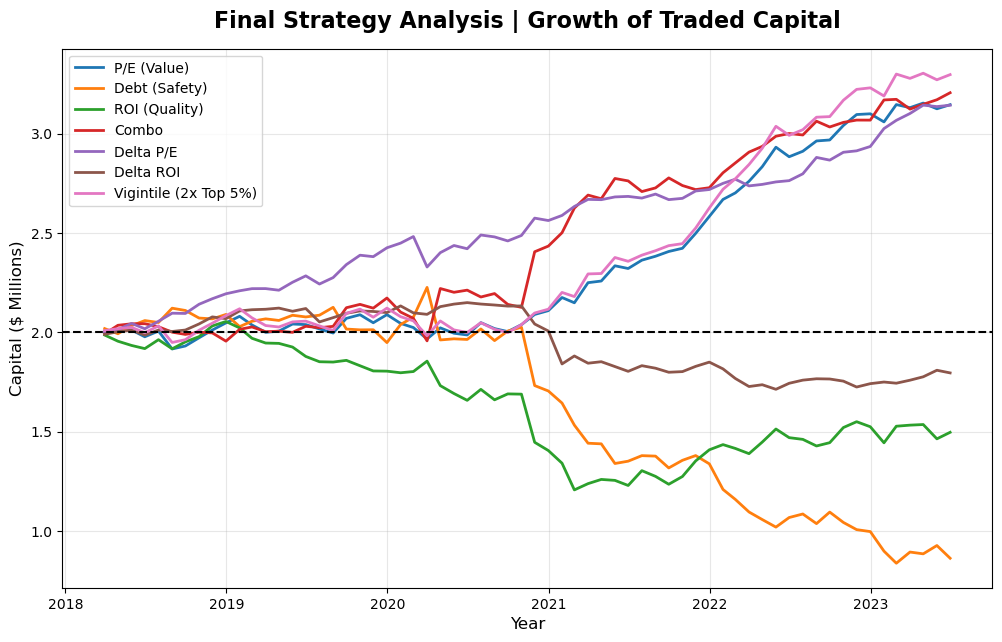

In [72]:
strategies = {
    "P/E (Value)": res_pe,
    "Debt (Safety)": res_debt,
    "ROI (Quality)": res_roi,
    "Combo": res_combo, 
    "Delta P/E": res_delta_pe,
    "Delta ROI": res_delta_roi, 
    "Vigintile (2x Top 5%)": res_weighted,
        }

plt.figure(figsize=(12, 7))

for name, df in strategies.items():
    df = df.sort_values('date')
    
    # Calculate Traded Equity (Start at $2M, remove Cash Drag)
    interest_est = df['capital'].shift(1).fillna(20_000_000) * df['risk_free_rate'] * (1/12)
    trading_pl = df['total_pl'] - interest_est
    
    # Cumulative Growth of $2M
    equity_curve = 2_000_000 + trading_pl.cumsum()
    
    plt.plot(df['date'], equity_curve / 1_000_000, label=name, linewidth=2)

plt.title("Final Strategy Analysis | Growth of Traded Capital", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Year", fontsize=12) 
plt.ylabel("Capital ($ Millions)", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.axhline(2.0, color='black', linestyle='--')

plt.show()

In [73]:
df_final_all # Display final results

,Strategy,Ann Ret (Port),Ann Vol (Port),Sharpe,Sortino,Max Drawdown,VaR (95%),CVaR (95%),Pure Ret,Pure Vol
0,P/E Ratio,4.90%,0.66%,1.37,NaN,-0.11%,0.13%,0.05%,10.73%,7.51%
1,Debt/Cap,3.07%,1.10%,-0.85,-0.74,-0.97%,-0.17%,-0.56%,-10.65%,12.23%
2,ROI,3.55%,0.85%,-0.52,-0.40,-0.86%,0.00%,-0.32%,-4.71%,9.44%
3,"Combined (High Debt, Low P/E, Low ROI)",4.97%,0.97%,1.00,NaN,-0.19%,0.11%,0.00%,11.30%,10.92%
4,Delta P/E (Multiple Contraction),4.93%,0.55%,1.71,NaN,-0.36%,0.20%,0.05%,10.71%,6.20%
5,Delta ROI (Improving Quality),3.84%,0.51%,-0.32,-0.20,-0.40%,0.13%,-0.08%,-1.91%,5.73%
6,Standard Decile (Top 10%),4.90%,0.66%,1.37,NaN,-0.11%,0.13%,0.05%,10.73%,7.51%
7,Weighted Vigintile (Top 5% x 2),5.02%,0.73%,1.41,6.38,-0.07%,0.13%,0.04%,12.15%,8.33%


Our results confirm that **Value (P/E Ratio)** is the primary driver of returns in this sample period. 
* The multi-factor composite (High Debt/Low P/E/Low ROI) expanded the pure return ceiling to 11.30%, but also brought significantly higher volatility. 
* The Weighted Vigintile experiment confirmed that this quantile ranking system works best at the extremes. By concentrating capital in the top 5% of the P/E Ratio distribution, the strategy achieved its peak Pure Return (12.15%) and Sharpe Ratio (1.41)
